In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Titanic Survival Prediction

## Objective
The goal of this project is to predict whether a passenger survived the Titanic disaster using machine learning models.

## Steps:
1. Data Loading
2. Data Preprocessing
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Model Comparison
7. Conclusion

In [ ]:
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp[mp>0].sort_values()

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [ ]:
# Handle Embarked
df_train = df_train.dropna(subset=["Embarked"])

# Fill Age
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Drop Cabin
df_train = df_train.drop("Cabin", axis=1)

In [ ]:
df_test = df_test.dropna(subset=["Fare"])
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test = df_test.drop("Cabin", axis=1)

In [ ]:
df_train.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
df_train = pd.get_dummies(df_train, drop_first=True)
df_test = pd.get_dummies(df_test, drop_first=True)

In [ ]:
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]

X_test = df_test.drop("Survived", axis=1)
y_test = df_test["Survived"]

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

KNN Results:
Accuracy: 0.8129496402877698
Precision: 0.7055555555555556
Recall: 0.8355263157894737
F1 Score: 0.7650602409638554


In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.9424460431654677
Precision: 0.9050632911392406
Recall: 0.9407894736842105
F1 Score: 0.9225806451612903


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)   # No scaling needed

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 0.7817745803357314
Precision: 0.672316384180791
Recall: 0.7828947368421053
F1 Score: 0.723404255319149


In [ ]:
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.812950,0.705556,0.835526,0.765060
1,Logistic Regression,0.942446,0.905063,0.940789,0.922581
2,Decision Tree,0.781775,0.672316,0.782895,0.723404


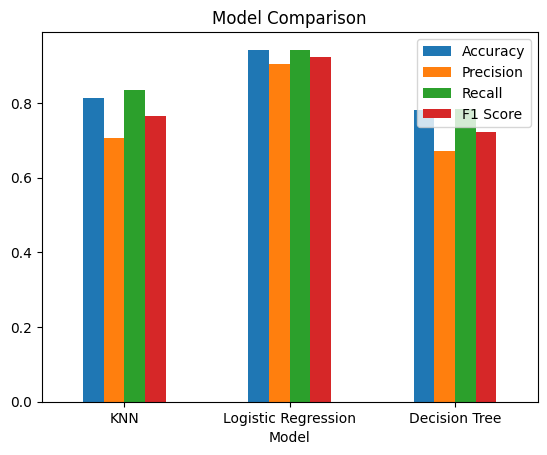

In [ ]:
results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [22]:
print(confusion_matrix(y_test, y_pred_knn))

[[212  53]
 [ 25 127]]
